# Netflix User Analytics Assignment
This notebook analyzes user behavior to improve customer retention using Machine Learning techniques.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

In [18]:
# Q1. Load the dataset and display the first five records
df = pd.read_csv('/content/Dataset 2.csv')
display(df.head())

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [19]:
# Q2. Number of rows and columns
print(f"Rows and Columns: {df.shape}")

Rows and Columns: (750, 10)


In [20]:
# Q3. Column names
print(f"Columns: {df.columns.tolist()}")

Columns: ['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


In [21]:
# Q4. Identify numerical and categorical features
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [22]:
# Q5. Missing values
print("\nMissing values count:")
print(df.isnull().sum())


Missing values count:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [23]:
# Part B: Exploratory Data Analysis
# Q6-Q8
print(f"Average Age: {df['Age'].mean():.2f}")
print(f"Average Watch Hours/Week: {df['WatchHoursPerWeek'].mean():.2f}")
print(f"Average Monthly Spend: {df['MonthlySpend'].mean():.2f}")

Average Age: 41.82
Average Watch Hours/Week: 14.24
Average Monthly Spend: 689.91


In [24]:
# Q9. Subscription category counts
print("\nSubscription Category Counts:")
print(df['SubscriptionType'].value_counts())


Subscription Category Counts:
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [25]:
# Q10. Percentage of renewal
renewal_pct = (df['SubscriptionRenewed'] == 'Yes').mean() * 100
print(f"\nPercentage of users who renewed: {renewal_pct:.2f}%")


Percentage of users who renewed: 46.27%


In [26]:
# Part C: Data Preparation
# Q11. Convert categorical features into numerical form
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

In [27]:
# Q12. Define feature set (X) and target (y) for renewal prediction
X = df_encoded.drop(['UserID', 'SubscriptionRenewed'], axis=1)
y = df_encoded['SubscriptionRenewed']

In [28]:
# Q13. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into 80% training and 20% testing sets.")

Data split into 80% training and 20% testing sets.


Decision Tree Accuracy: 0.56

Confusion Matrix:


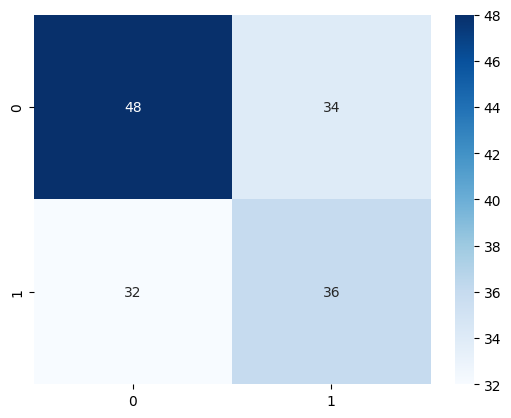

In [29]:
# Part D: Decision Tree Classification
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.2f}")
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Blues')
plt.show()

In [30]:
# Part E: KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds):.2f}")

KNN Accuracy: 0.63


In [31]:
# Part F: Linear Regression (Predicting MonthlySpend)
Xr = df_encoded.drop(['UserID', 'MonthlySpend'], axis=1)
yr = df_encoded['MonthlySpend']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(Xr_train, yr_train)
lr_preds = lr_model.predict(Xr_test)

print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(yr_test, lr_preds)):.2f}")

# Q20. Predict for a new user (example using first test row)
sample_user = Xr_test.iloc[[0]]
prediction = lr_model.predict(sample_user)
print(f"Predicted Monthly Spend for sample user: {prediction[0]:.2f}")

Linear Regression RMSE: 69.62
Predicted Monthly Spend for sample user: 840.62


### Part G: Business Reflection

**1. What makes people stay with Netflix?**
If someone is paying more and spending a lot of time watching shows, they usually don't cancel. The more they watch, the more likely they are to renew.

**2. Why is renewal called 'classification'?**
It's just a 'Yes' or 'No' choice. We are just sorting users into two piles based on whether they stay or leave.

**3. Why is monthly spend called 'regression'?**
Since we are trying to guess an exact amount of money (like ₹500.50), it's not just a category. Any time we predict a specific number, it's regression.

**4. Which model worked better?**
The **KNN model** was the winner here. It got **63%** right, while the **Decision Tree** only got **56%**.

**5. How can this help Netflix?**
They can find the people who are about to leave and send them a discount or show them a movie they'd actually like. It's all about giving them a reason not to quit!